### Plots for Word Frequency

In [3]:
import pandas as pd

# Replace 'data_cleaned.csv' with your actual file path if needed
data_cleaned = pd.read_csv('Data/data_cleaned.csv')

from collections import Counter

#Create a word frequency count
# Create an empty dictionary to store counters for each target
word_freq_by_target = {}

# Loop through each unique target
for target in data_cleaned['target'].unique():
    # Filter rows for the current target
    target_df = data_cleaned[data_cleaned['target'] == target]
    
    # Combine all clean_text into one big string
    all_text = " ".join(target_df['clean_text'].dropna().astype(str))
    
    # Tokenize by splitting on whitespace (assuming clean_text is already cleaned)
    words = all_text.split()
    
    # Count word frequencies
    word_counter = Counter(words)
    
    # Store the 10 most common words for this target
    word_freq_by_target[target] = word_counter.most_common(10)

# Display the results
for target, word_list in word_freq_by_target.items():
    print(f"\nTarget: {target}")
    for word, freq in word_list:
        print(f"  {word}: {freq}")


Target: gender
  women: 62559
  protest: 28796
  violence: 18964
  woman: 18124
  members: 17228
  city: 16816
  people: 16575
  held: 13998
  police: 13838
  staged: 12864

Target: health
  health: 33538
  workers: 30387
  protest: 19182
  hospital: 18048
  medical: 10567
  city: 9797
  demand: 9529
  staged: 9225
  protested: 8512
  doctors: 8337

Target: journalists
  journalists: 15331
  journalist: 8700
  city: 7382
  media: 7164
  police: 6656
  protest: 6434
  arrest: 6109
  arrested: 4861
  group: 4603
  protested: 3859

Target: peacekepers
  forces: 871
  monusco: 780
  group: 692
  fatalities: 649
  killed: 577
  peacekeepers: 558
  minusma: 538
  around: 481
  minusca: 458
  fardc: 455


In [4]:
#Turn into a frequency table
# Flatten the dictionary into rows
rows = []
for target, word_list in word_freq_by_target.items():
    for word, freq in word_list:
        rows.append({'target': target, 'word': word, 'frequency': freq})

# Create DataFrame
freq_df = pd.DataFrame(rows)

#Preview
print(freq_df.head(15))

    target      word  frequency
0   gender     women      62559
1   gender   protest      28796
2   gender  violence      18964
3   gender     woman      18124
4   gender   members      17228
5   gender      city      16816
6   gender    people      16575
7   gender      held      13998
8   gender    police      13838
9   gender    staged      12864
10  health    health      33538
11  health   workers      30387
12  health   protest      19182
13  health  hospital      18048
14  health   medical      10567


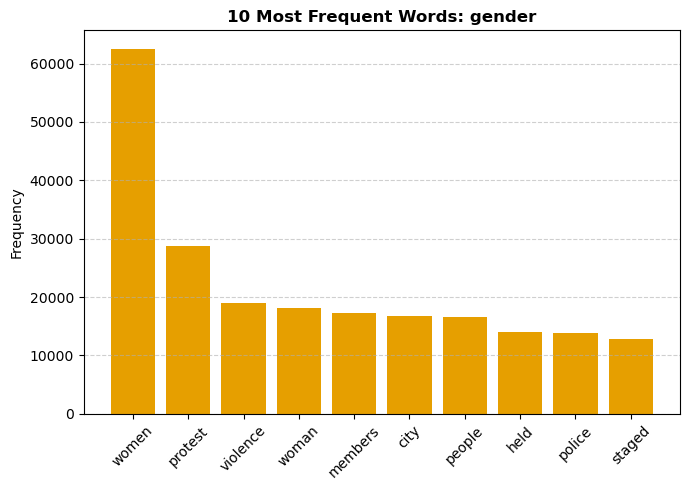

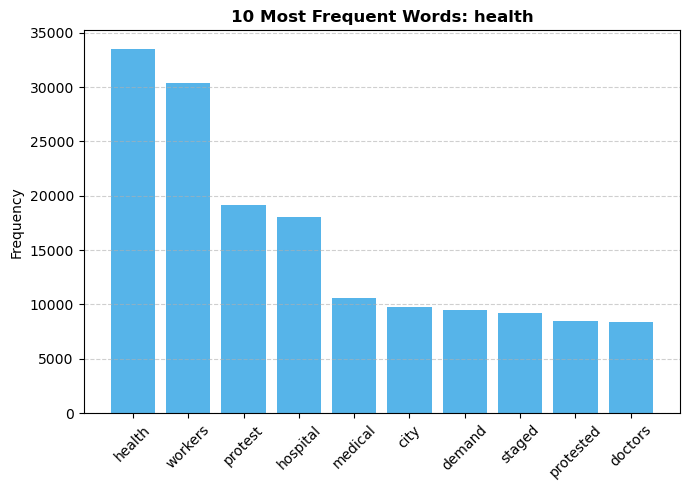

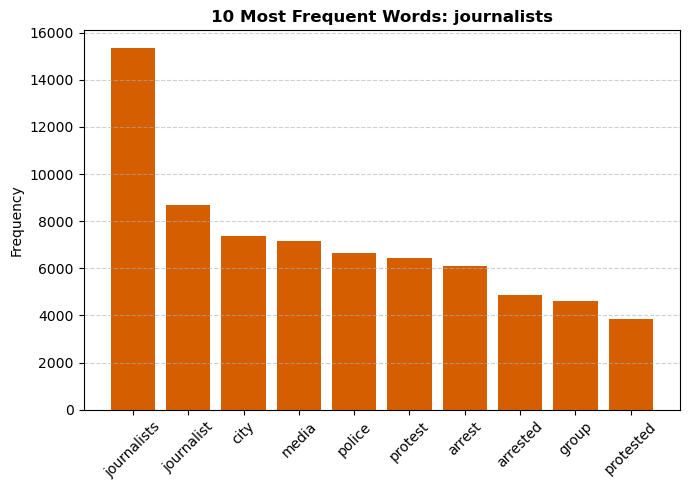

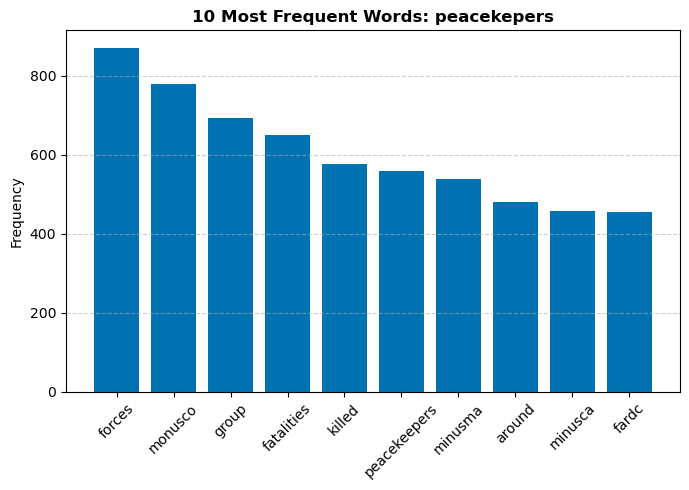

In [5]:
import matplotlib.pyplot as plt

# Professional color palette
colors = ['#E69F00', '#56B4E9', '#D55E00', '#0072B2']

# One plot per target
for i, (target, word_list) in enumerate(word_freq_by_target.items()):
    words, freqs = zip(*word_list)
    
    plt.figure(figsize=(7, 5))
    plt.bar(words, freqs, color=colors[i % len(colors)])
    plt.title(f"10 Most Frequent Words: {target}", fontsize=12, fontweight='bold')
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the plot
    filename = f"word_frequency_{str(target).lower().replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300)
    
    # Show the plot
    plt.show()

    # Close to avoid overlap in next figure
    plt.close()
